In [1]:
pip install tensorflow


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 45ms/step - accuracy: 0.3525 - loss: 1.7540 - val_accuracy: 0.5508 - val_loss: 1.2640
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.5783 - loss: 1.1819 - val_accuracy: 0.6405 - val_loss: 1.0330
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.6495 - loss: 0.9990 - val_accuracy: 0.6486 - val_loss: 1.0217
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6905 - loss: 0.8836 - val_accuracy: 0.6772 - val_loss: 0.9353
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.7189 - loss: 0.8019 - val_accuracy: 0.6874 - val_loss: 0.8993
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.7375 - loss: 0.7510 - val_accuracy: 0.6975 - val_loss: 0.9042
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7524 - loss: 0.6948 - val_accuracy: 0.7082 - val_loss: 0.8677
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.7758 -

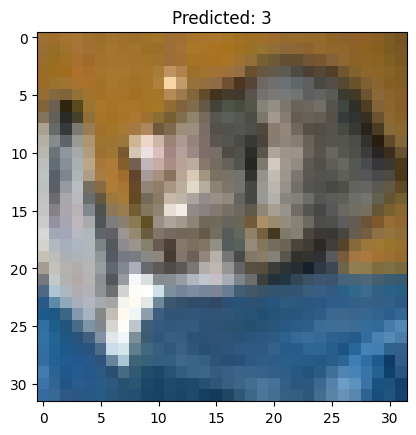

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize the pixel values (from 0 to 255) to (0 to 1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),  # Conv Layer 1
    layers.MaxPooling2D((2, 2)),  # MaxPooling Layer 1
    layers.Conv2D(64, (3, 3), activation='relu'),  # Conv Layer 2
    layers.MaxPooling2D((2, 2)),  # MaxPooling Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),  # Conv Layer 3
    layers.Flatten(),  # Flatten the 3D matrix to 1D
    layers.Dense(64, activation='relu'),  # Fully connected layer
    layers.Dense(10)  # Output layer (10 classes for CIFAR-10)
])

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy :', test_acc)

# Predict on a test image
predictions = model.predict(x_test)
print("\nPredicted class for the first image:", predictions[0].argmax())

# Display the first image and its predicted class
plt.imshow(x_test[0])
plt.title(f"Predicted: {predictions[0].argmax()}")
plt.show()














